# Yaw Steering for Solar Power Optimisation

Demonstrates the effect of yaw steering on solar power generation.

**Scenario**
- 450 km circular orbit, 50° inclination, nadir-pointed
- Single deployed solar panel: 5 m² active area, normal direction (1, 0, −1) in body frame
- 30% solar-to-DC efficiency
- Comparison: fixed nadir attitude vs yaw steering

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from missiontools import Spacecraft, FixedAttitudeLaw, NormalVectorSolarConfig

## 1. Spacecraft and solar panel setup

In [2]:
EPOCH = np.datetime64('2025-03-20T12:00:00', 'us')

PANEL_AREA    = 5.0    # m² gross
FILL_FACTOR   = 0.95
EFFICIENCY    = 0.30
PANEL_NORMAL  = [1, 0, -1]  # body frame (normalised internally)

active_area = PANEL_AREA * FILL_FACTOR

print(f"Panel gross area  : {PANEL_AREA:.1f} m\u00b2")
print(f"Active cell area  : {active_area:.2f} m\u00b2")
print(f"Panel normal      : {PANEL_NORMAL}")
print(f"Efficiency        : {EFFICIENCY:.0%}")

Panel gross area  : 5.0 m²
Active cell area  : 4.75 m²
Panel normal      : [1, 0, -1]
Efficiency        : 30%


In [3]:
sc_static = Spacecraft(
    a     = (6_371_000 + 450_000),  # 450 km altitude
    e     = 0.0,
    i     = np.radians(50.0),
    raan  = 0.0,
    arg_p = 0.0,
    ma    = 0.0,
    epoch = EPOCH,
)

cfg_static = NormalVectorSolarConfig(
    normal_vecs=[PANEL_NORMAL],
    areas=[active_area],
    efficiency=EFFICIENCY,
)
sc_static.add_solar_config(cfg_static)

mu = sc_static.central_body_mu
period_s = 2 * np.pi * np.sqrt(sc_static.a**3 / mu)
period   = np.timedelta64(int(period_s * 1e6), 'us')

print(f"Altitude          : 450 km")
print(f"Inclination       : 50.0\u00b0")
print(f"Orbital period    : {period_s / 60:.1f} min")

Altitude          : 450 km
Inclination       : 50.0°
Orbital period    : 93.4 min


## 2. Static attitude — power over one orbit

In [4]:
result_static = cfg_static.generation(EPOCH, EPOCH + period, np.timedelta64(10, 's'))
oap_static    = cfg_static.oap()

print(f"OAP (static)      : {oap_static:.2f} W")
print(f"Peak power        : {result_static['power'].max():.2f} W")

OAP (static)      : 596.12 W
Peak power        : 1946.52 W


## 3. Yaw steering — power over one orbit

In [5]:
# Build a second spacecraft with yaw steering enabled
sc_yaw = Spacecraft(
    a     = sc_static.a,
    e     = 0.0,
    i     = np.radians(50.0),
    raan  = 0.0,
    arg_p = 0.0,
    ma    = 0.0,
    epoch = EPOCH,
)

cfg_yaw = NormalVectorSolarConfig(
    normal_vecs=[PANEL_NORMAL],
    areas=[active_area],
    efficiency=EFFICIENCY,
)
sc_yaw.add_solar_config(cfg_yaw)
sc_yaw.attitude_law.yaw_steering(cfg_yaw)

result_yaw = cfg_yaw.generation(EPOCH, EPOCH + period, np.timedelta64(10, 's'))
oap_yaw    = cfg_yaw.oap()

print(f"OAP (yaw steering): {oap_yaw:.2f} W")
print(f"Peak power        : {result_yaw['power'].max():.2f} W")

OAP (yaw steering): 1004.05 W
Peak power        : 1946.55 W


## 4. Comparison plots

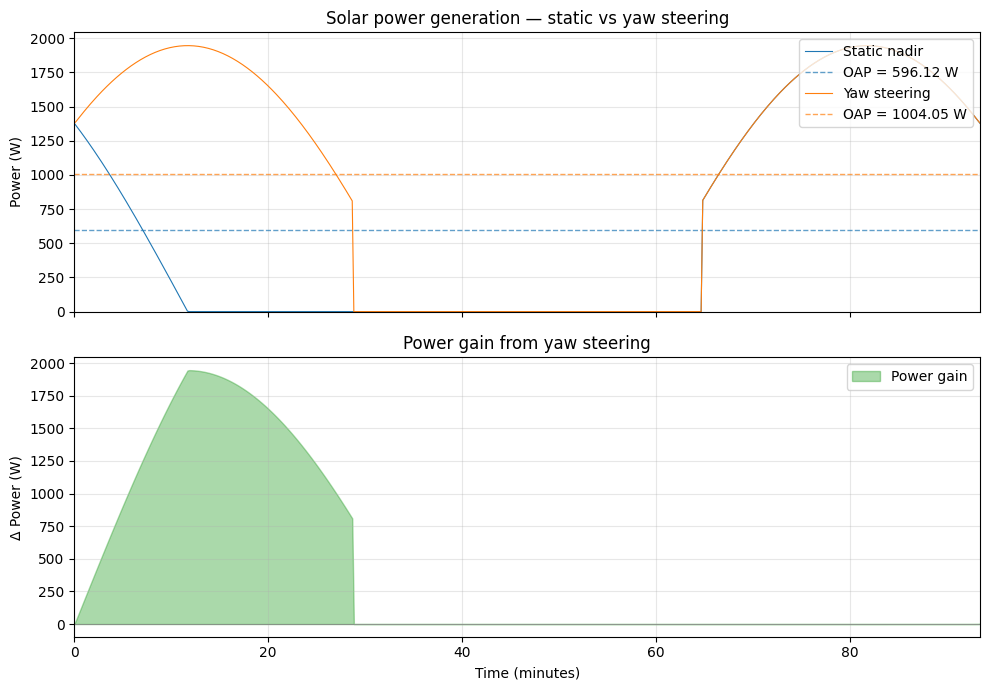

In [6]:
elapsed_static = (result_static['t'] - result_static['t'][0]) / np.timedelta64(1, 'm')
elapsed_yaw    = (result_yaw['t']    - result_yaw['t'][0])    / np.timedelta64(1, 'm')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# --- Individual curves ---
ax1.plot(elapsed_static, result_static['power'], linewidth=0.8, color='tab:blue', label='Static nadir')
ax1.axhline(oap_static, color='tab:blue', linestyle='--', linewidth=1, alpha=0.7,
            label=f'OAP = {oap_static:.2f} W')
ax1.plot(elapsed_yaw, result_yaw['power'], linewidth=0.8, color='tab:orange', label='Yaw steering')
ax1.axhline(oap_yaw, color='tab:orange', linestyle='--', linewidth=1, alpha=0.7,
            label=f'OAP = {oap_yaw:.2f} W')
ax1.set_ylabel('Power (W)')
ax1.set_title('Solar power generation \u2014 static vs yaw steering')
ax1.legend(loc='upper right')
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)

# --- Power gain ---
gain = result_yaw['power'] - result_static['power']
ax2.fill_between(elapsed_yaw, gain, alpha=0.4, color='tab:green', label='Power gain')
ax2.axhline(0, color='grey', linewidth=0.5)
ax2.set_xlabel('Time (minutes)')
ax2.set_ylabel('\u0394 Power (W)')
ax2.set_title('Power gain from yaw steering')
ax2.legend()
ax2.set_xlim(0, elapsed_yaw[-1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Summary

In [7]:
improvement = (oap_yaw / oap_static - 1) * 100

print('=' * 50)
print('Yaw steering summary')
print('=' * 50)
print(f"{'':25} {'Static':>12} {'Yaw':>12}")
print('-' * 50)
print(f"{'OAP (W)':25} {oap_static:>12.2f} {oap_yaw:>12.2f}")
print(f"{'Peak power (W)':25} {result_static['power'].max():>12.2f} {result_yaw['power'].max():>12.2f}")
print(f"{'OAP improvement':25} {'+' + f'{improvement:.1f}':>12}%")

Yaw steering summary
                                Static          Yaw
--------------------------------------------------
OAP (W)                         596.12      1004.05
Peak power (W)                 1946.52      1946.55
OAP improvement                  +68.4%
